# Operando imaging of ionic memory in 2D nanochannels: minimal analysis example

Companion notebook to

> K. V. Saurav, N. Ronceray, B. Coquinot, A. D. Pizarro, A. Keerthi, T. Emmerich, A. Radenovic & R. Boya.
> **Direct imaging elucidates ionic memory in two-dimensional nanochannels.** *Nature Materials* (2026).
> [doi:10.1038/s41563-026-02775-4](https://doi.org/10.1038/s41563-026-02775-4)

It walks through the core of the correlative (electrokinetic + optical) analysis on a single recording of **Device 1**
(hBN / five-layer graphene / hBN, 1 M KCl, sinusoidal drive $\Delta V(t) = \Delta V_0 \sin(2\pi f t)$ with $\Delta V_0 = 1$ V and $f = 100$ mHz), the device of Figs. 2 and 4 of the paper:

1. **Electrokinetic data**: load the recording, average it over each camera frame, and plot the I–V characteristic and conductance $G(t)$
2. **Voltage-induced contrast** (VIC) $\Psi$ computed from the synchronised reflectance images, and mapped at $\pm 1$ V
3. **Individual blisters**: $\Psi(t)$ alongside $G(t)$, and $\Psi$–$V$ characteristics
4. **Kymograph** of the VIC along a line
5. **Blister descriptors**: symmetry ratio $S$ and contrast–conductance correlation $C$

It is meant as a readable starting point, not as a script regenerating every figure of the paper.

## 0. Setup

**Data.** Download the two files of the folder **`Raw Data Device 1 (1M KCl, +-1V)`** from figshare
([doi:10.6084/m9.figshare.33269229](https://doi.org/10.6084/m9.figshare.33269229)) and place them in a `data/` folder next to this notebook:

| file | content |
|---|---|
| `<STEM>_iv.csv` | EK recording at 1 kHz: time, camera exposure trigger, applied voltage, current |
| `<STEM>_img.tif` | 401 reflectance frames, 1000 × 1000 px, 16 bit (≈ 0.8 GB) |

**Requirements.** `numpy`, `scipy`, `pandas`, `matplotlib`, `scikit-image`, `tifffile` (see `requirements.txt`). The notebook runs in under a minute and needs ≈ 1.5 GB of RAM.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
from scipy import ndimage
from scipy.signal import find_peaks
from skimage.transform import rotate

plt.rcParams.update({'figure.dpi': 110, 'font.size': 8})
VIC_STYLE = dict(cmap='seismic', vmin=-1, vmax=1)   # colour scale used for all VIC images

In [2]:
# --- data --------------------------------------------------------------------------
DATA_DIR = Path('data')
STEM = '241201_123908_1M_KCl_1V_0.1hz_4_1000H_1000W_N401'   # <STEM>_iv.csv + <STEM>_img.tif

# --- Device 1 geometry, only used to draw the theoretical bulk conductance ------------
SIGMA = 11.16        # conductivity of 1 M KCl (S/m)
H_CH = 1.70e-9       # channel height, five-layer graphene spacer (m)
W_CH = 100e-9        # width of one channel (m)
L_CH = 4.8e-6        # channel length (m)
N_CH = 44            # number of parallel channels

# --- image processing --------------------------------------------------------------
BINNING = 2          # 2 x 2 pixel binning (denoising, lighter data)
ROTATION_DEG = 119.5 # rotation bringing the channel region vertical

## 1. Electrokinetic data

The CSV holds the voltage applied by the digital–analogue converter and the measured current, sampled at 1 kHz, together with the camera exposure trigger.
The image stack contains one reference frame at rest, $\eta(0)$, followed by one frame per 100-ms trigger period.
Frame $n \geq 1$ is therefore matched to the mean of the EK samples of trigger period $n-1$.

The dashed line in the I–V plot is the conductance expected from the bulk conductivity and the channel geometry, $G_\mathrm{theo} = \sigma N w h / L$ (cf. Fig. 2a,d).

In [3]:
ek = pd.read_csv(DATA_DIR / f'{STEM}_iv.csv')
t = ek['Time [s]'].to_numpy()
V = ek['Voltage out [V]'].to_numpy()
I = 1e3 * ek['Current [A]'].to_numpy()   # current column is stored in µA -> nA
ek.head()

,Time [s],Image exposure,Voltage out [V],Current [A]
0,0.000,1.0,0.000000,0.001782
1,0.001,1.0,0.000628,0.001914
2,0.002,1.0,0.001257,0.002039
3,0.003,1.0,0.001885,0.002159
4,0.004,1.0,0.002513,0.002274


In [4]:
stack = tifffile.memmap(DATA_DIR / f'{STEM}_img.tif')   # (frame, y, x), read lazily from disk
n = len(stack) - 1          # number of frames under voltage (frame 0 is the reference)
k = len(t) // n             # EK samples per frame period

def per_frame(x):
    # average EK samples over each frame period
    return x[:n * k].reshape(n, k).mean(axis=1)

t_f, V_f, I_f = per_frame(t), per_frame(V), per_frame(I)
G_f = np.where(np.abs(V_f) > 1e-2, I_f / V_f, np.nan)   # conductance (nS)

print(f'{len(stack)} frames of {stack.shape[1]} x {stack.shape[2]} px, '
      f'{k} EK samples ({t[k] - t[0]:.2f} s) per frame')

401 frames of 1000 x 1000 px, 100 EK samples (0.10 s) per frame


G_theo = 17.4 nS


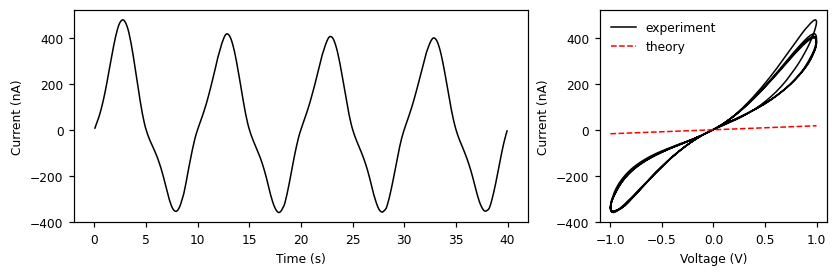

In [5]:
G_theo = SIGMA * N_CH * W_CH * H_CH / L_CH * 1e9   # theoretical conductance (nS)
print(f'G_theo = {G_theo:.1f} nS')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 2.4), width_ratios=[2, 1], layout='constrained')
ax1.plot(t_f, I_f, 'k', lw=1)
ax1.set(xlabel='Time (s)', ylabel='Current (nA)')

ax2.plot(V_f, I_f, 'k', lw=1, label='experiment')
ax2.plot([-1, 1], [-G_theo, G_theo], 'r--', lw=1, label='theory')
ax2.set(xlabel='Voltage (V)', ylabel='Current (nA)')
ax2.legend(frameon=False);

## 2. Voltage-induced contrast

Each frame is binned 2 × 2 and rotated so that the channel region is vertical.
The VIC of each pixel is the Michelson contrast between the image under voltage and the reference image at rest (Eq. 1 of the paper):

$$\Psi(\Delta V) = \frac{\eta(\Delta V) - \eta(0)}{\eta(\Delta V) + \eta(0)} \in [-1, 1].$$

$\Psi$ is model-independent. Its sign and magnitude depend on the layer stack, and a transfer-matrix calculation (Fig. 1e, Supplementary Section 5) converts it into an order-of-magnitude blister height.

In [6]:
def bin_image(img, b):
    # average b x b pixel blocks
    h, w = img.shape[0] // b * b, img.shape[1] // b * b
    return img[:h, :w].reshape(h // b, b, w // b, b).mean(axis=(1, 3))

def preprocess(frame):
    return rotate(bin_image(frame.astype(np.float32), BINNING), ROTATION_DEG, preserve_range=True)

ref = preprocess(stack[0])                            # eta(0)
vic = np.empty((n, *ref.shape), dtype=np.float32)     # Psi, one map per frame, aligned with t_f
with np.errstate(divide='ignore', invalid='ignore'):
    for i in range(n):
        img = preprocess(stack[i + 1])                # eta(dV)
        vic[i] = (img - ref) / (img + ref)
vic[:, ~ndimage.binary_erosion(ref > 0, iterations=5)] = np.nan   # empty corners left by the rotation

### VIC maps at ±1 V (cf. Fig. 2e)

Localised features of positive or negative contrast appear under voltage: liquid-filled blisters formed by the voltage-driven delamination of the confining walls.

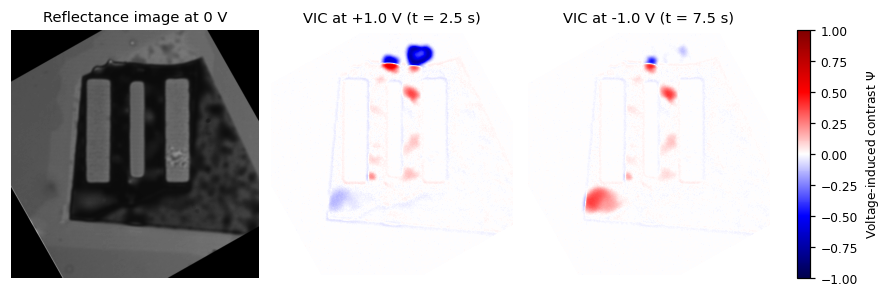

In [7]:
i_pos, i_neg = np.argmax(V_f), np.argmin(V_f)

fig, axs = plt.subplots(1, 3, figsize=(8, 2.9), layout='constrained')
axs[0].imshow(ref, cmap='gray')
axs[0].set_title('Reflectance image at 0 V')
for ax, i in zip(axs[1:], (i_pos, i_neg)):
    im = ax.imshow(vic[i], **VIC_STYLE)
    ax.set_title(f'VIC at {V_f[i]:+.1f} V (t = {t_f[i]:.1f} s)')
for ax in axs:
    ax.axis('off')
fig.colorbar(im, ax=axs[1:], shrink=0.8, label='Voltage-induced contrast $\\Psi$');

## 3. Individual blisters (cf. Fig. 4a,c,e)

Regions of interest (ROIs) on the blisters labelled 1b, 1c and 1d in Figs. 4 and 5, given as `(y0, y1, x0, x1)` in the binned, rotated images.
To follow other features, add or edit entries.

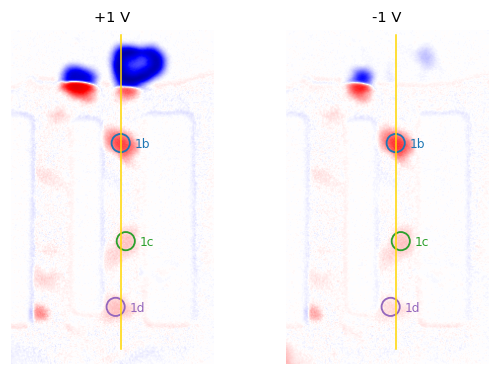

In [8]:
ROIS = {'1b': (126, 128, 288, 290),
        '1c': (223, 225, 293, 295),
        '1d': (288, 290, 283, 285)}
COLORS = {'1b': 'tab:blue', '1c': 'tab:green', '1d': 'tab:purple'}
KYMO_X, KYMO_Y = 289, slice(20, 330)   # vertical line through the three blisters (Section 4)

fig, axs = plt.subplots(1, 2, figsize=(5, 3.3), layout='constrained')
for ax, i in zip(axs, (i_pos, i_neg)):
    ax.imshow(vic[i], **VIC_STYLE)
    ax.plot([KYMO_X, KYMO_X], [KYMO_Y.start, KYMO_Y.stop], color='gold', lw=1)
    for name, (y0, y1, x0, x1) in ROIS.items():
        ax.add_patch(plt.Circle(((x0 + x1 - 1) / 2, (y0 + y1 - 1) / 2), 9, fill=False, ec=COLORS[name], lw=1.2))
        ax.text(x1 + 12, (y0 + y1) / 2, name, color=COLORS[name], va='center')
    ax.set(xlim=(180, 380), ylim=(345, 15), title=f'{V_f[i]:+.0f} V')
    ax.axis('off')

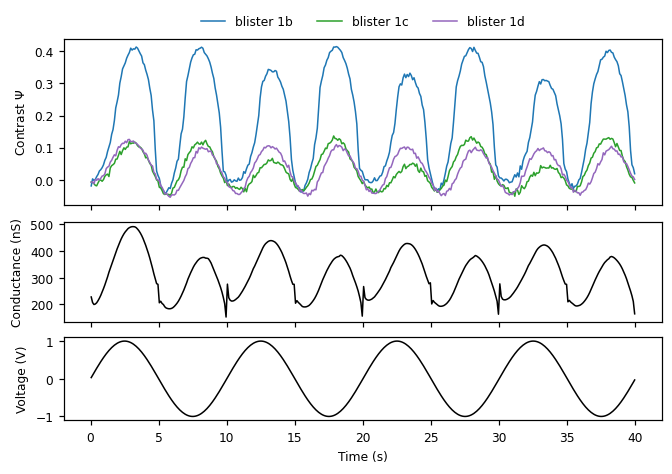

In [9]:
psi = {name: np.nanmean(vic[:, y0:y1, x0:x1], axis=(1, 2)) for name, (y0, y1, x0, x1) in ROIS.items()}

fig, axs = plt.subplots(3, 1, figsize=(6, 4.2), sharex=True, height_ratios=[2, 1.2, 1], layout='constrained')
for name, trace in psi.items():
    axs[0].plot(t_f, trace, color=COLORS[name], lw=1, label=f'blister {name}')
axs[0].set_ylabel('Contrast $\\Psi$')
axs[0].legend(frameon=False, ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1))
axs[1].plot(t_f, G_f, 'k', lw=1)
axs[1].set_ylabel('Conductance (nS)')
axs[2].plot(t_f, V_f, 'k', lw=1)
axs[2].set(xlabel='Time (s)', ylabel='Voltage (V)');

The blisters swell and recede at every voltage cycle, in step with the conductance. Blister 1b swells at both polarities.
Their $\Psi$–$V$ characteristics show hysteresis loops, like the memristive I–V characteristic of Section 1.

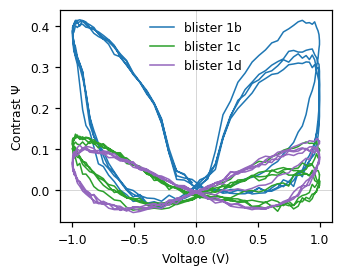

In [10]:
fig, ax = plt.subplots(figsize=(3, 2.4), layout='constrained')
for name, trace in psi.items():
    ax.plot(V_f, trace, color=COLORS[name], lw=1, label=f'blister {name}')
ax.axhline(0, color='0.8', lw=0.5, zorder=0)
ax.axvline(0, color='0.8', lw=0.5, zorder=0)
ax.set(xlabel='Voltage (V)', ylabel='Contrast $\\Psi$')
ax.legend(frameon=False);

## 4. Kymograph (cf. Fig. 3b)

The VIC along a line (gold line above) as a function of time, correlated with the conductance.
This decomposes the conductance trace into the contributions of the blisters crossed by the line.

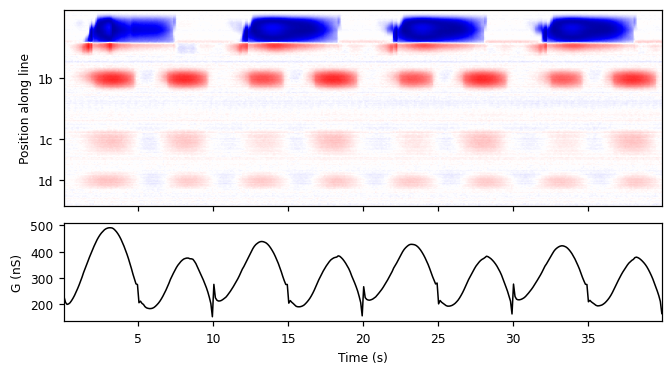

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 3.3), sharex=True, height_ratios=[2, 1], layout='constrained')
ax1.imshow(vic[:, KYMO_Y, KYMO_X].T, **VIC_STYLE, aspect='auto',
           extent=(t_f[0], t_f[-1], KYMO_Y.stop, KYMO_Y.start))
ax1.set_yticks([(y0 + y1) / 2 for y0, y1, _, _ in ROIS.values()], labels=list(ROIS))
ax1.set_ylabel('Position along line')
ax2.plot(t_f, G_f, 'k', lw=1)
ax2.set(xlabel='Time (s)', ylabel='G (nS)');

## 5. Blister descriptors (cf. Fig. 5)

Two descriptors summarise how each blister responds to the drive and how it relates to ion transport. Both are computed for each voltage cycle and then averaged.

* **Symmetry ratio** $S = A_\mathrm{small} / A_\mathrm{large}$, where $A_\pm$ is the area under $\Psi(t)$ over the positive or negative half-cycle.
  $S \approx 1$ for bidirectional blisters and $S \ll 1$ for unidirectional ones.
* **Contrast–conductance correlation** $C = \langle \delta G(t) \times |\Psi(t)| \rangle$, with the normalised conductance variation
  $\delta G = (G - G_\mathrm{min}) / (G_\mathrm{max} - G_\mathrm{min})$. $G_\mathrm{min}$ is taken as the 10th percentile of $G(t)$ for robustness to noise.

In [12]:
def split_cycles(v):
    # index bounds of full drive cycles, centred on the maxima of the sinusoidal voltage
    peaks, _ = find_peaks(v)
    half = int(round(np.median(np.diff(peaks)))) // 2
    bounds = np.r_[max(peaks[0] - half, 0), (peaks[:-1] + peaks[1:]) // 2, min(peaks[-1] + half, len(v))]
    return list(zip(bounds[:-1], bounds[1:]))

def blister_descriptors(psi, G, v):
    # symmetry ratio S and contrast-conductance correlation C, mean and s.d. over drive cycles
    G_min = np.nanquantile(G, 0.1)
    dG = (G - G_min) / (np.nanmax(G) - G_min)
    S, C = [], []
    for a, b in split_cycles(v):
        A_pos = abs(np.mean(psi[a:b][v[a:b] > 0]))   # proportional to the area under Psi(t), V > 0
        A_neg = abs(np.mean(psi[a:b][v[a:b] < 0]))
        S.append(min(A_pos, A_neg) / max(A_pos, A_neg))
        C.append(np.nanmean(dG[a:b] * np.abs(psi[a:b])))
    return pd.Series({'S': np.mean(S), 'S s.d.': np.std(S), 'C': np.mean(C), 'C s.d.': np.std(C)})

published = pd.DataFrame({'S (Fig. 5)': [0.644, 0.142, 0.702], 'C (Fig. 5)': [0.105, 0.024, 0.027]},
                         index=['1b', '1c', '1d'])
descriptors = pd.DataFrame({name: blister_descriptors(trace, G_f, V_f) for name, trace in psi.items()}).T
descriptors.join(published).round(3)

,S,S s.d.,C,C s.d.,S (Fig. 5),C (Fig. 5)
1b,0.644,0.115,0.104,0.014,0.644,0.105
1c,0.117,0.091,0.023,0.005,0.142,0.024
1d,0.713,0.268,0.027,0.005,0.702,0.027


## Going further

* **Other blisters, recordings or devices**: edit `ROIS`, or `STEM`, `ROTATION_DEG` and `ROIS` for another recording. The ROI traces $\Psi(t)$, together with `t_f`, `G_f` and `V_f`, are all that is needed to compute $S$ and $C$.
  The statistics of Fig. 5 use these same descriptors for $N = 50$ blisters from 9 devices.
* **Contrast-to-height conversion**: the transfer-matrix calculation of Fig. 1e (Supplementary Section 5) is not included here.